# DA5401: A5: Visualizing Data Veracity Challenges in Multi-Label Classification

In [301]:
# importing packages
import pandas as pd 
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm

if not hasattr(cm, "register_cmap"):
    def register_cmap(*args, **kwargs):
        pass
    cm.register_cmap = register_cmap
    
import seaborn as sns
from collections import Counter
import warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, silhouette_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import ClusterCentroids

from sklearn.cluster import KMeans

from kneed import KneeLocator
from sklearn.mixture import GaussianMixture

from scipy.io import arff
from collections import Counter
from sklearn.manifold import TSNE, Isomap

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [2]:
# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

---
## Part A: Preprocessing and Initial Setup [10 points]
---

### Overview of Yeast Dataset [Mulan Repository] 
The Yeast dataset is a well-known benchmark for multi-label classification. Here is an overview addressing your specific points.

### Origin & Context
The dataset is derived from a study on gene functional analysis in **Saccharomyces cerevisiae** (baker's yeast). It is used to predict the functional class of a gene based on its gene expression data. It is a canonical example of a multi-label classification problem where each instance (gene) can belong to multiple categories simultaneously.


### Size & Records
The dataset contains a total of **2,417 records** or instances, with each record representing a single yeast gene. This size makes it manageable for a variety of machine learning algorithms.

### Class Distribution
The dataset has **14 possible class labels**, labeled `Class1` through `Class14`. Each gene can be associated with one or more of these classes, indicated by a binary value (0 or 1) for each class. The distribution is generally imbalanced, with some classes being much more prevalent than others. This imbalance is a common challenge in multi-label datasets.


### Features & Characteristics
The dataset is composed of **103 numeric attributes** or features. These attributes are denoted as `Att1` through `Att103` and correspond to various gene expression measurements. The data is pre-normalized or scaled, as the values are small decimals, suggesting they have been transformed from their raw state. This is a crucial characteristic for analysis as it eliminates the need for initial data scaling.

### 1. Load and Prepare the Dataset

In [49]:
# Load the dataset
df_arff = arff.loadarff('./yeast.arff')
df = pd.DataFrame(df_arff[0])

# View first 5 samples
print("\nTop 5 Samples")
print("-" * 40)
df.head()


Top 5 Samples
----------------------------------------


,Att1,Att2,Att3,Att4,Att5,Att6,Att7,Att8,Att9,Att10,...,Class5,Class6,Class7,Class8,Class9,Class10,Class11,Class12,Class13,Class14
0,0.004168,-0.170975,-0.156748,-0.142151,0.058781,0.026851,0.197719,0.041850,0.066938,-0.056617,...,b'0',b'0',b'1',b'1',b'0',b'0',b'0',b'1',b'1',b'0'
1,-0.103956,0.011879,-0.098986,-0.054501,-0.007970,0.049113,-0.030580,-0.077933,-0.080529,-0.016267,...,b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0'
2,0.509949,0.401709,0.293799,0.087714,0.011686,-0.006411,-0.006255,0.013646,-0.040666,-0.024447,...,b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'1',b'1',b'0'
3,0.119092,0.004412,-0.002262,0.072254,0.044512,-0.051467,0.074686,-0.007670,0.079438,0.062184,...,b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0'
4,0.042037,0.007054,-0.069483,0.081015,-0.048207,0.089446,-0.004947,0.064456,-0.133387,0.068878,...,b'1',b'1',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0'


In [203]:
# Separate features and labels
# Typically, the last 14 columns are labels
X_values = df.iloc[:, :-14].values
Y_values = df.iloc[:, -14:].values.astype(int)


# Dimensionality Check
print("\nDimensionality Check")
print("-" * 40)
print(f"Number of features: {X.shape[1]}", f"[{df.columns[0]} --> {df.columns[-15]}]")
print(f"Number of data points: {X.shape[0]}")
print(f"Number of labels: {Y.shape[1]}",f"[{df.columns[-14]} --> {df.columns[-1]}]")


Dimensionality Check
----------------------------------------
Number of features: 103 [Att1 --> Att103]
Number of data points: 2417
Number of labels: 16 [Class1 --> Class14]


In [204]:
# Check for missing values
print(f"\nMissing values per column:")
print("-" * 40)
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print(" No missing values found in the dataset")
else:
    print(missing_values[missing_values > 0])


Missing values per column:
----------------------------------------
 No missing values found in the dataset


In [205]:
print(f"\nBasic statistics for X:")
print("-" * 40)
df.iloc[:, :-14].describe()


Basic statistics for X:
----------------------------------------


,Att1,Att2,Att3,Att4,Att5,Att6,Att7,Att8,Att9,Att10,...,Att94,Att95,Att96,Att97,Att98,Att99,Att100,Att101,Att102,Att103
count,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,...,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000,2417.000000
mean,0.001173,-0.000436,-0.000257,0.000265,0.001228,0.000475,0.001107,0.000420,0.001076,-0.000009,...,-0.000773,0.000464,-0.000515,0.000667,0.000324,-0.001483,-0.001047,-0.001539,0.000284,0.007605
std,0.097411,0.097885,0.097746,0.096969,0.096909,0.097306,0.097170,0.096803,0.096326,0.096805,...,0.093316,0.096684,0.096209,0.096635,0.096280,0.094369,0.096900,0.094211,0.093154,0.099368
min,-0.371146,-0.472632,-0.339195,-0.467945,-0.367044,-0.509447,-0.319928,-0.594498,-0.369712,-0.767128,...,-0.455191,-0.283594,-0.279408,-0.226420,-0.225374,-0.501572,-0.236589,-0.267052,-0.194079,-0.237752
25%,-0.053655,-0.058734,-0.057526,-0.057149,-0.058461,-0.060212,-0.058445,-0.062849,-0.063472,-0.065010,...,-0.054133,-0.056415,-0.056414,-0.059382,-0.058025,-0.053591,-0.063318,-0.059542,-0.054078,-0.077191
50%,0.003649,-0.003513,0.002892,-0.000153,0.005565,0.000321,0.006179,0.001436,0.003515,0.002432,...,-0.012893,-0.023595,-0.024313,-0.023059,-0.021942,-0.018216,-0.033623,-0.023519,-0.012007,0.022126
75%,0.057299,0.048047,0.061007,0.054522,0.066286,0.059908,0.068892,0.061418,0.064958,0.063096,...,0.027977,0.034937,0.036057,0.041430,0.035730,0.019583,0.038901,0.025408,0.028087,0.103185
max,0.520272,0.614114,0.353241,0.568960,0.307649,0.336971,0.351401,0.454591,0.419852,0.420876,...,0.609175,0.542867,0.547134,0.385928,0.540493,0.569250,0.509963,0.587358,0.700340,0.163431


Insights:

* **Cleanliness**: With a consistent count of **2417** across all 103 attributes, there are no missing values in the dataset.
* **Standardization**: The data has been extensively pre-processed. The means are very close to **0**, and the standard deviations are uniformly low (around **0.09-0.1**), indicating the features are on a standardized scale, likely through methods such as Z-score normalization.
* **Centralized Distribution**: The minimum, 25th percentile, 50th percentile (median), 75th percentile, and maximum values all confirm that the data is tightly clustered around **0**, with a consistent distribution across all attributes.

In [206]:
print(f"\nBasic statistics for Y:")
print("-" * 40)
df.iloc[:, -14:].describe()


Basic statistics for Y:
----------------------------------------


,Class1,Class2,Class3,Class4,Class5,Class6,Class7,Class8,Class9,Class10,Class11,Class12,Class13,Class14
count,2417,2417,2417,2417,2417,2417,2417,2417,2417,2417,2417,2417,2417,2417
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'1',b'1',b'0'
freq,1655,1379,1434,1555,1695,1820,1989,1937,2239,2164,2128,1816,1799,2383


In [259]:
X = df.iloc[:, :-14].astype(float)
Y = df.iloc[:, -14:].astype(int)


# -----------------------------
# Label Simplification for Visualization
# -----------------------------
label_sums = Y.sum(axis=1)  # count active labels per sample
Y["label_pattern"] = [tuple(row) for row in Y.values]

# Convert label matrix to label combinations
label_combinations = []
for i in range(len(Y)):
    labels = tuple(np.where(Y.iloc[i,:] == 1)[0])
    label_combinations.append(labels)

# Count frequency of each combination
label_counter = Counter(label_combinations)
most_common = label_counter.most_common(20)

print(f"Total unique label combinations: {len(label_counter)}")
print(f"\nTop 5 most frequent label combinations:")
for combo, count in most_common[:5]:
    print(f"  Labels {combo}: {count} samples ({count/len(Y)*100:.1f}%)")


# Find the two most frequent single-label classes
single_label_combos = [(combo, count) for combo, count in most_common if len(combo) == 1]
top_single_labels = single_label_combos[:2] if len(single_label_combos) >= 2 else single_label_combos
print(f"\nTop single label combinations:")
for combo, count in top_single_labels:
    print(f"  Labels {combo}: {count} samples ({count/len(Y)*100:.1f}%)")
#print(f"  Labels {top_single_labels}: {top_single_labels} samples ({count/len(Y)*100:.1f}%)")

# Find top two single-label classes
single_label_rows = Y[label_sums == 1]
single_counts = single_label_rows.drop(columns="label_pattern").sum().sort_values(ascending=False)
#print(single_label_rows)
top_single_labels = single_counts.index[:2].tolist()


# Find most frequent multi-label combination
multi_label_rows = Y[label_sums > 1]
most_common_multi = multi_label_rows["label_pattern"].value_counts().idxmax()

# Assign new simplified category
def assign_category(row):
    pattern = tuple(row[:-1])  # exclude 'pattern' column
    if sum(pattern) == 1:
        label_name = Y.columns[:-1][np.argmax(pattern)]
        if label_name in top_single_labels:
            return label_name
    if pattern == most_common_multi:
        return "Most_Frequent_Multi"
    return "Other"

Y["Category"] = Y.apply(assign_category, axis=1)

print("\nCategory Summary")
print("-" * 40)
print(Y["Category"].value_counts())


Total unique label combinations: 198

Top 5 most frequent label combinations:
  Labels (2, 3, 11, 12): 237 samples (9.8%)
  Labels (3, 4, 11, 12): 233 samples (9.6%)
  Labels (0, 1, 11, 12): 172 samples (7.1%)
  Labels (0, 1): 131 samples (5.4%)
  Labels (1, 2, 11, 12): 117 samples (4.8%)

Top single label combinations:
  Labels (0,): 32 samples (1.3%)

Category Summary
----------------------------------------
Category
Other                  2148
Most_Frequent_Multi     237
Class1                   32
Name: count, dtype: int64


New Class Distribution:
----------------------------------------


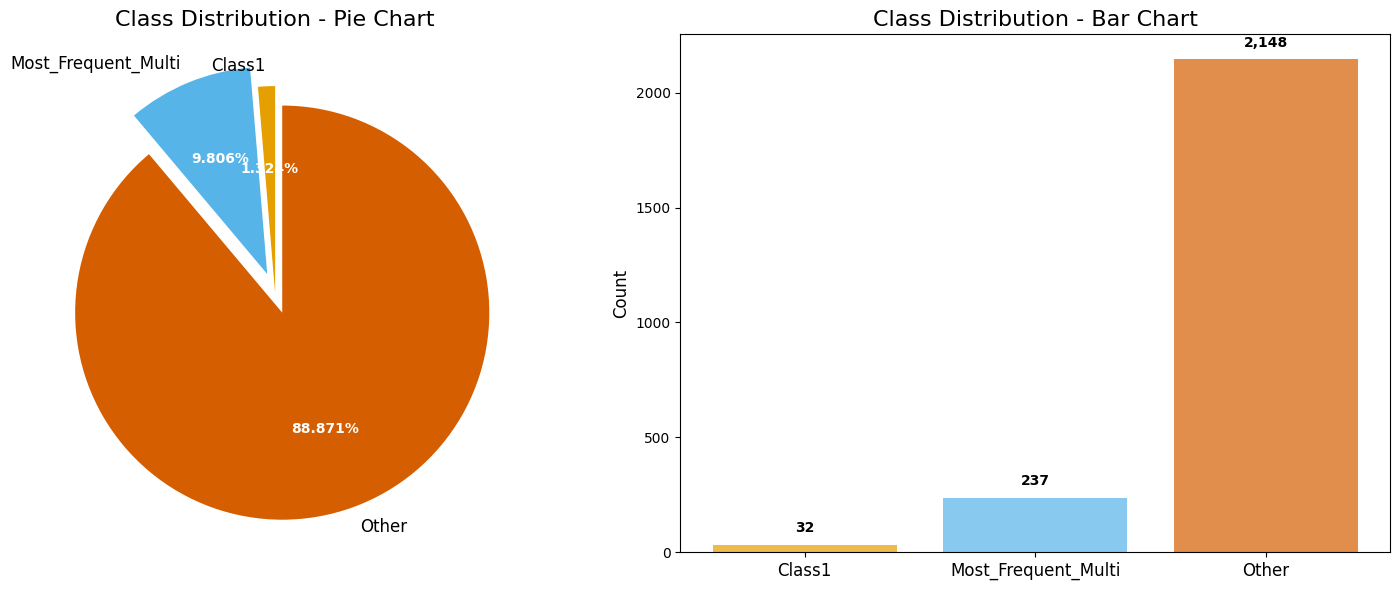

In [200]:
# Calculate class distribution
class_counts = Y['Category'].value_counts().sort_index()
class_percentages = Y['Category'].value_counts(normalize=True).sort_index() * 100

new_labels = class_counts.index

print("New Class Distribution:")
print("-" * 40)
# Create visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart
colors = ['#E69F00',  # orange
          '#56B4E9',  # sky blue
          '#D55E00',]  # vermilion (reddish-brown)  
wedges, texts, autotexts = ax1.pie(class_counts.values, 
                                  labels=new_labels,
                                  autopct='%1.3f%%',
                                  colors=colors,
                                  startangle=90,
                                  explode=(0, 0.1,0.1))  

ax1.set_title('Class Distribution - Pie Chart', fontsize=16)#, fontweight='bold')

# Make percentage text more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
for autotext in texts:
    autotext.set_fontsize(12)
# Bar plot
bars = ax2.bar(class_counts.index, class_counts.values, color=colors, alpha=0.7)
#ax2.set_xlabel('Class', fontweight='bold')
ax2.set_ylabel('Count',fontsize=12)
ax2.set_title('Class Distribution - Bar Chart', fontsize=16,)# fontweight='bold')
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(new_labels,fontsize=12)

# Add value labels on bars
for bar, count in zip(bars, class_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



### Why Scaling is Essential for Distance-Based Dimensionality Reduction (t-SNE, Isomap)

**1. Uneven Feature Spread:**
  Even though most attributes have near-zero means, their standard deviations vary (≈0.09 – 0.10).
  Without scaling, attributes with slightly larger dispersion (e.g., Att1 vs. Att94) will dominate pairwise distances, overshadowing subtler yet important patterns.

**2. Inconsistent Feature Ranges:**
  Minimum and maximum values differ across features (e.g., Att10 ranges from –0.76 to 0.42, while Att98 ranges –0.22 to 0.54).
  Such range disparities distort the geometry of the data manifold — points may appear closer or farther apart simply because of scale differences, not actual similarity.

**3. Distorted Neighborhood Relationships:**
  Algorithms like **t-SNE** and **Isomap** preserve local neighborhoods based on distances.
  If a few high-variance features dominate, neighborhood structure becomes biased, leading to misleading clusters and artificial separations in the low-dimensional embedding.

**4. Slow or Unstable Optimization:**
  The unbalanced magnitudes across 103 features can make the optimization landscape highly uneven.
  This leads to **poor convergence**, requiring more iterations and often ending in suboptimal embeddings.

**5. Misleading Interpretability:**
  When embeddings are influenced by unscaled magnitudes, the resulting visualization reflects **feature scale bias** rather than true data relationships — masking real biological or statistical structure.

**6. Why Standardization Helps:**
  Applying **z-score normalization** (mean = 0, std = 1) equalizes all features’ contributions to distance computations.
  It ensures every attribute — regardless of original variance or range — influences the manifold learning process **equally and fairly**, preserving genuine geometry.




In [214]:
# Apply standardization
scaler = StandardScaler()
X = X_values
X_scaled = scaler.fit_transform(X)

print(f"Applied StandardScaler")
print("-" * 40)
print(f"  Original X \n\t- Mean: {X.mean():.4f}, Std: {X.std():.4f}")
print(f"  Scaled X \n\t- Mean: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")

Applied StandardScaler
----------------------------------------
  Original X 
	- Mean: 0.0001, Std: 0.0985
  Scaled X 
	- Mean: 0.0000, Std: 1.0000


---
## Part B: t-SNE and Veracity Inspection [20 points]
---

### **What is t-Distributed Stochastic Neighbor Embedding (t-SNE)?**

t-SNE is a powerful **non-linear dimensionality reduction technique**, widely used to visualize high-dimensional datasets in a low-dimensional space, usually 2D or 3D. It is particularly effective at uncovering hidden structures in complex data, such as clusters, patterns, or local groupings that linear methods like PCA might miss.

##### How t-SNE Works

t-SNE maps high-dimensional data to a lower-dimensional space while attempting to **preserve the relative similarities** between points. The process involves two main steps:

1. **Measuring High-Dimensional Similarities**:
   For each data point, t-SNE computes the probability that another point is its neighbor, assuming a Gaussian distribution centered around each point. Nearby points have a higher probability of being considered neighbors, whereas distant points have a lower probability.

2. **Mapping to Low-Dimensional Space**:
   t-SNE creates a low-dimensional representation where points maintain these similarity relationships. It uses a **Student's t-distribution** with one degree of freedom (which has heavier tails than a Gaussian) to calculate similarities in the low-dimensional space. This helps reduce the **crowding problem**, where points tend to cluster near the center of the plot.

   The algorithm then applies **gradient descent** to iteratively reposition points, minimizing the difference between high-dimensional and low-dimensional similarity distributions, typically measured using **Kullback-Leibler divergence**. The result is a visualization where similar points cluster together and dissimilar points are farther apart.

##### Key Features and Considerations

* **Perplexity**:
  A critical hyperparameter that reflects the effective number of neighbors each point considers. Lower values focus on local relationships, while higher values capture broader global structures. Common choices range from **5 to 50**, but the optimal value depends on dataset size and complexity.

* **Non-Linear Relationships**:
  Unlike linear techniques, t-SNE can model **complex, non-linear patterns**, making it ideal for datasets with intricate cluster structures.

* **Stochastic Nature**:
  t-SNE starts with a random initialization and employs stochastic optimization. As a result, multiple runs with the same settings can yield slightly different visualizations. Running the algorithm several times or using a fixed random seed helps achieve more stable results.

* **Computational Considerations**:
  t-SNE can be **computationally intensive**, especially for large datasets, due to the pairwise distance calculations. Variants like **Barnes-Hut t-SNE** or **FIt-SNE** improve efficiency for larger datasets.

* **Distance Preservation**:
  t-SNE emphasizes preserving **local structures** over global distances. While clusters are meaningful, the distances between clusters are less interpretable.



##### t-SNE vs PCA

| Feature            | t-SNE                                             | PCA                                                |
|-------------------|--------------------------------------------------|---------------------------------------------------|
| Method            | Non-linear                                        | Linear                                            |
| Goal              | Visualization and cluster identification. Preserves local structure. | Feature extraction and data compression. Preserves global variance. |
| Output            | Can reveal distinct, separated clusters.        | Projects data onto a new coordinate system that maximizes variance. |
| Computational Cost | High, especially for large datasets.           | Low, computationally efficient.                  |
| Interpretability  | Less interpretable; the axes and distances don't have direct meaning. | Highly interpretable; components represent directions of maximum variance. |


### **What is Veracity Inspection?**

**Veracity inspection**, which represents "Ensuring Data Reliability", is the process of evaluating the **accuracy, reliability, and trustworthiness** of data or information. In the era of **big data**, veracity is considered one of the **four Vs**—Volume, Variety, Velocity, and Veracity—highlighting the importance of data quality alongside quantity and speed.
* **Low-Veracity Data**: Data that is noisy, inconsistent, incomplete, or contains errors. Examples include faulty sensor readings, user-generated content with misinformation, or datasets with missing metadata. Using such data can lead to incorrect insights and unreliable predictions.
* **High-Veracity Data**: Clean, accurate, and well-documented data that provides confidence in analysis and modeling. This type of data forms a solid foundation for robust insights and informed decision-making.






In [284]:
print("\nt-SNE Implementation")
print("-" * 40)

# Experiment with different perplexity values
perplexity_values = [5, 30, 50]
tsne_results = {}
tsne_kld = {}

print("\nExperimenting with different perplexity values:")
for perp in perplexity_values:
    print(f"\n  Testing perplexity = {perp}...")
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, 
                max_iter=1000, verbose=0)
    X_tsne = tsne.fit_transform(X_scaled)
    tsne_results[perp] = X_tsne
    print(f"    Completed (KL divergence: {tsne.kl_divergence_:.4f})")
    tsne_kld[perp] = tsne.kl_divergence_



t-SNE Implementation
----------------------------------------

Experimenting with different perplexity values:

  Testing perplexity = 5...
    Completed (KL divergence: 2.0449)

  Testing perplexity = 30...
    Completed (KL divergence: 2.1655)

  Testing perplexity = 50...
    Completed (KL divergence: 2.0798)


In [269]:
label_map = {}
for idx,name in enumerate(Y['Category'].unique()):
    label_map[name] = idx
categorical_index = Y['Category'].map(label_map)
category_names = Y['Category'].unique()


t-SNE Visualization
----------------------------------------


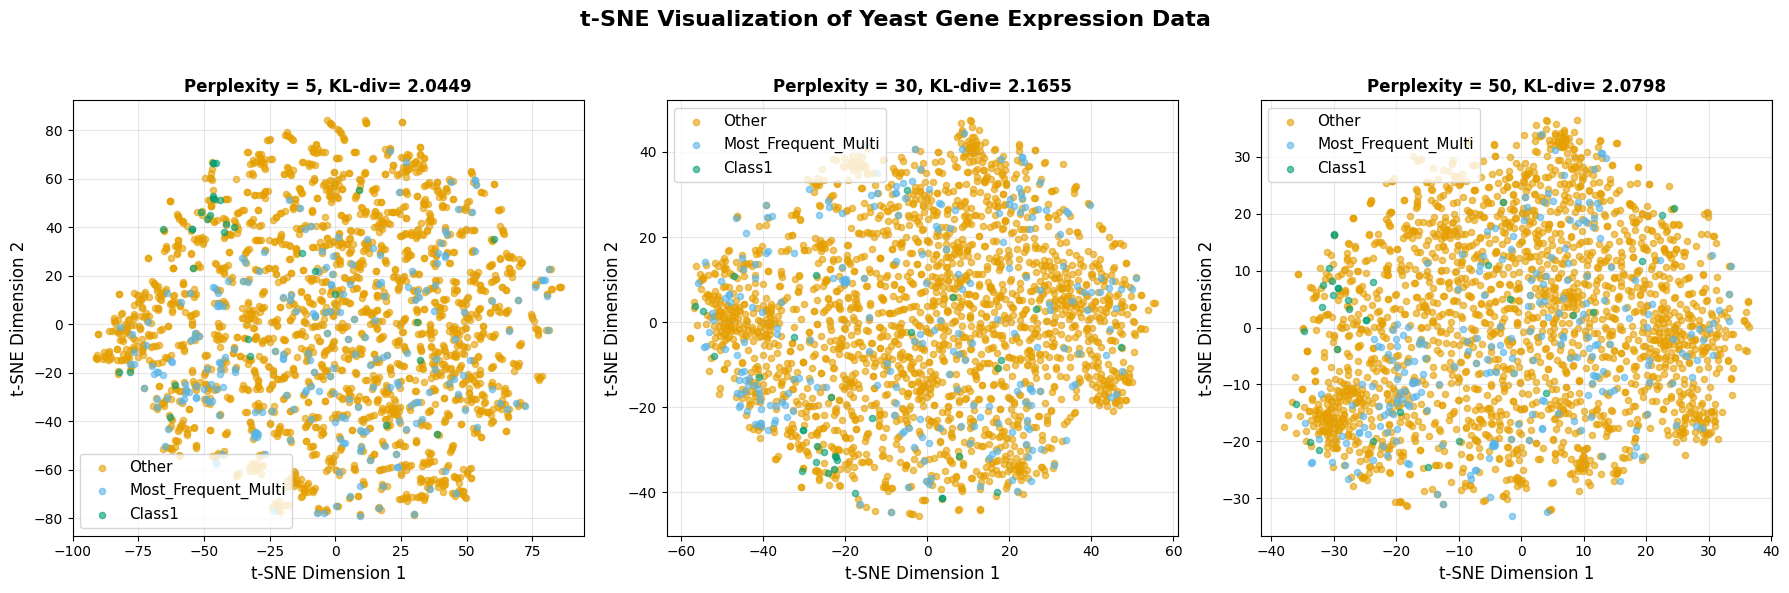

In [287]:
# Task 2: Visualization
print("\nt-SNE Visualization")
print("-" * 40)

# Create color palette
colors = ['#E69F00',  # orange
          '#56B4E9',  # sky blue
          '#009E73',  # bluish green
          '#F0E442']  # yellow
color_map = [colors[idx] for idx in categorical_index]

# Create figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('t-SNE Visualization of Yeast Gene Expression Data', 
             fontsize=16, fontweight='bold')

# Plot for each perplexity
for idx, (perp, ax) in enumerate(zip(perplexity_values, axes)):
    X_tsne = tsne_results[perp]
    
    for cat_idx, name in enumerate(category_names):
        mask = categorical_index == cat_idx
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                   c=colors[cat_idx], label=name, alpha=0.6, s=20)
    
    ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
    ax.set_title(f'Perplexity = {perp}, KL-div= {tsne_kld[perp]:.4f}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit suptitle
plt.show()


**Insights**:

The three t-SNE plots show the same yeast gene expression data visualized with different perplexity values: 5, 30, and 50. The perplexity hyperparameter roughly relates to the number of neighbors a point considers, influencing the balance between preserving local and global data structures.

**Perplexity = 5**: This low value overemphasizes local similarities, causing the data to fragment into many small, distinct clusters. The "Class1" and "Most_Frequent_Multi" clusters are highly fragmented and dispersed, making it difficult to discern any clear, coherent patterns. The visualization appears noisy and lacks a clear global structure.

**Perplexity = 30**: This is the sweet spot. With a value of 30, the algorithm effectively identifies and groups the "Class1" and "Most_Frequent_Multi" points into more cohesive clusters. The separation between these classes and the large "Other" group is much clearer than in the 5-perplexity plot. The clusters are still distinct enough to show local patterns but are not so fragmented as to lose their overall structure.

**Perplexity = 50**: This higher value focuses too much on global relationships. The clusters begin to merge, and the distinct separation seen at a perplexity of 30 starts to disappear. While it captures the overall shape of the data, the fine-grained, local clustering of "Class1" and "Most_Frequent_Multi" is less pronounced, making it harder to distinguish these groups from the rest of the data.

The Kullback-Leibler (KL) divergence values (2.0449 for perplexity 5, 2.1655 for perplexity 30, and 2.0798 for perplexity 50) also support this conclusion. Although the lowest divergence indicates a better fit, the goal of t-SNE is visualization and interpretability, not just optimization. A slightly higher KL divergence for a perplexity of 30 is acceptable because the resulting plot provides the most meaningful and visually coherent separation of the classes, which is the primary objective of using t-SNE for this kind of data.

So, We choose **Perplexity = 30** as the best case.


Final t-SNE Visualization (perplexity=30)
----------------------------------------


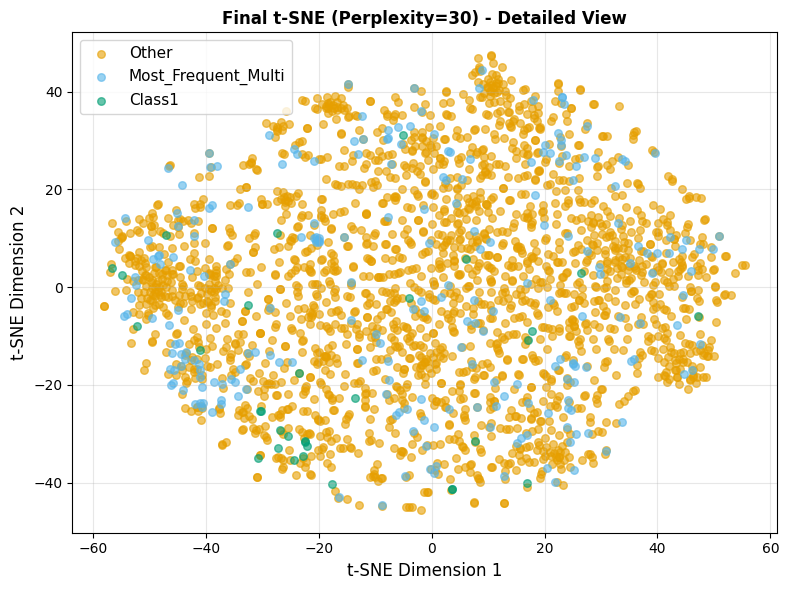

In [293]:
# Use perplexity=30 for final analysis
X_tsne_final = tsne_results[30]

# Task 2: Visualization
print("\nFinal t-SNE Visualization (perplexity=30)")
print("-" * 40)

# Create color palette
colors = ['#E69F00',  # orange
          '#56B4E9',  # sky blue
          '#009E73',  # bluish green
          '#F0E442']  # yellow
color_map = [colors[idx] for idx in categorical_index]

# Final selected visualization (perplexity=30) in a separate figure
plt.figure(figsize=(8, 6))  # set figure size

for cat_idx, name in enumerate(category_names):
    mask = categorical_index == cat_idx
    plt.scatter(X_tsne_final[mask, 0], X_tsne_final[mask, 1], 
                c=colors[cat_idx], label=name, alpha=0.6, s=30)

plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('Final t-SNE (Perplexity=30) - Detailed View', fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Veracity Inspection [ Final t-SNE Visualization (perplexity=30)] 
----------------------------------------


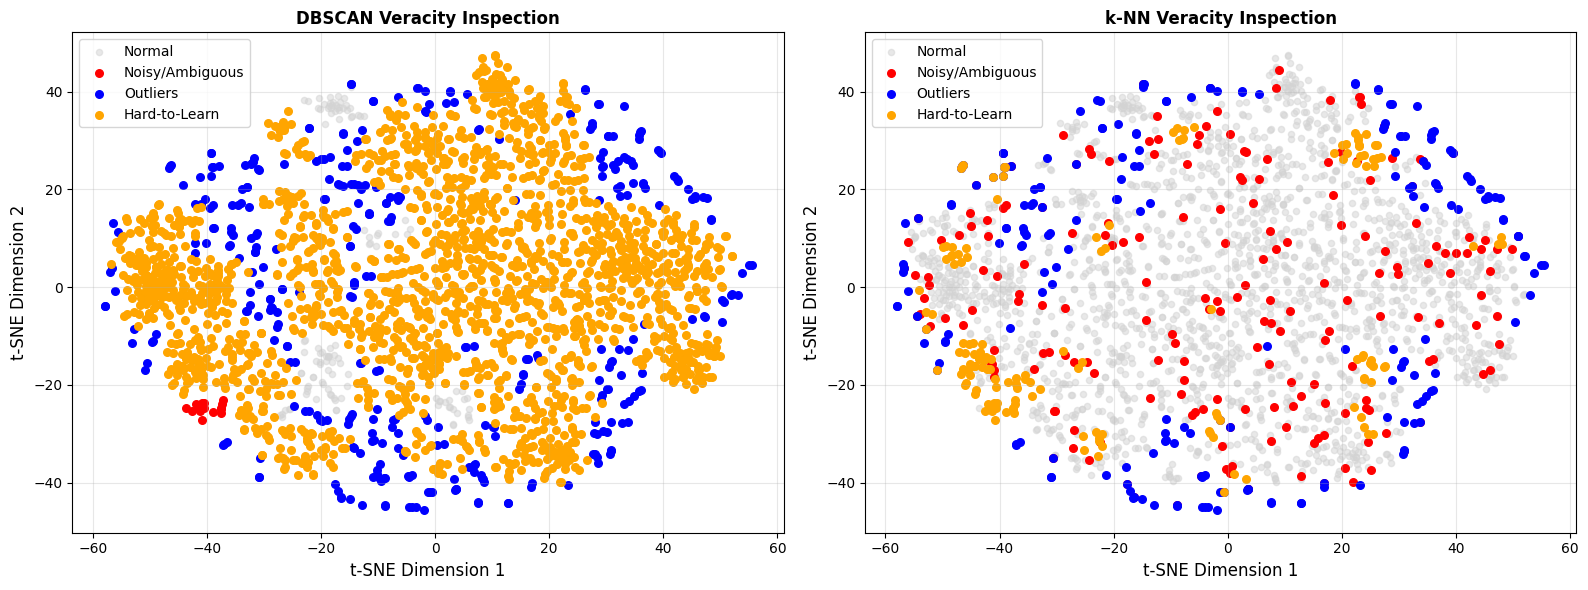

In [305]:
print("\nVeracity Inspection [ Final t-SNE Visualization (perplexity=30)] ")
print("-" * 40)
# --- DBSCAN setup ---
eps = 3.0
min_samples = 10 # empherically chosen for samples > 1000
db = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = db.fit_predict(X_tsne_final)

outlier_mask_db = labels_db == -1
noisy_mask_db = np.zeros(X_tsne_final.shape[0], dtype=bool)
hard_mask_db = np.zeros(X_tsne_final.shape[0], dtype=bool)

unique_clusters = set(labels_db) - {-1}
for cluster in unique_clusters:
    cluster_idx = np.where(labels_db == cluster)[0]
    cluster_labels = categorical_index[cluster_idx]
    counts = np.bincount(cluster_labels)
    dominant_fraction = counts.max() / counts.sum()
    
    if dominant_fraction < 0.7:
        noisy_mask_db[cluster_idx] = True
    elif 0.7 <= dominant_fraction < 0.95:
        hard_mask_db[cluster_idx] = True

# --- k-NN setup ---
k = 10 # empherically chosen for samples > 1000
outlier_dist_threshold = 3.0

nbrs = NearestNeighbors(n_neighbors=k+1).fit(X_tsne_final)
distances, indices = nbrs.kneighbors(X_tsne_final)

noisy_mask_knn = np.zeros(X_tsne_final.shape[0], dtype=bool)
hard_mask_knn = np.zeros(X_tsne_final.shape[0], dtype=bool)
outlier_mask_knn = np.mean(distances[:, 1:], axis=1) > outlier_dist_threshold

for i, neighbors in enumerate(indices):
    neighbors = neighbors[neighbors != i]
    neighbor_labels = categorical_index[neighbors]
    fraction_different = np.mean(neighbor_labels != categorical_index[i])
    
    if fraction_different > 0.7:
        noisy_mask_knn[i] = True
    elif fraction_different > 0.3:
        hard_mask_knn[i] = True

# --- Plotting side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN
axes[0].scatter(X_tsne_final[:, 0], X_tsne_final[:, 1], c='lightgray', alpha=0.5, s=20, label='Normal')
axes[0].scatter(X_tsne_final[noisy_mask_db, 0], X_tsne_final[noisy_mask_db, 1], c='red', s=30, label='Noisy/Ambiguous')
axes[0].scatter(X_tsne_final[outlier_mask_db, 0], X_tsne_final[outlier_mask_db, 1], c='blue', s=30, label='Outliers')
axes[0].scatter(X_tsne_final[hard_mask_db, 0], X_tsne_final[hard_mask_db, 1], c='orange', s=30, label='Hard-to-Learn')
axes[0].set_title('DBSCAN Veracity Inspection', fontsize=12, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1',fontsize=12)
axes[0].set_ylabel('t-SNE Dimension 2',fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# k-NN
axes[1].scatter(X_tsne_final[:, 0], X_tsne_final[:, 1], c='lightgray', alpha=0.5, s=20, label='Normal')
axes[1].scatter(X_tsne_final[noisy_mask_knn, 0], X_tsne_final[noisy_mask_knn, 1], c='red', s=30, label='Noisy/Ambiguous')
axes[1].scatter(X_tsne_final[outlier_mask_knn, 0], X_tsne_final[outlier_mask_knn, 1], c='blue', s=30, label='Outliers')
axes[1].scatter(X_tsne_final[hard_mask_knn, 0], X_tsne_final[hard_mask_knn, 1], c='orange', s=30, label='Hard-to-Learn')
axes[1].set_title('k-NN Veracity Inspection', fontsize=12, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1',fontsize=12)
axes[1].set_ylabel('t-SNE Dimension 2',fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Veracity Inspection
Why choose both DBScan and KNN?

We choose botht the DBSCAN and KNN methods to justify our answers as we think not a single algorithm would give better justification as all have their advantages and disadvantages.Using both the DBSCAN and k-NN plots is essential for a comprehensive veracity analysis because they each highlight different aspects of the data. The **DBSCAN** plot is an objective tool for identifying **outliers** and the fundamental, density-based clusters. It reveals which samples are truly part of a coherent group and which are isolated as "noise" due to their low-density location. In contrast, the **k-NN** plot is crucial for understanding **classification challenges** and the relationships between different labeled groups. It visually shows how a simple classifier would partition the data, making it the best tool for identifying "hard-to-learn samples"—those areas where different classes are thoroughly mixed. It also helps to find "noisy/ambiguous labels" by showing points that are incorrectly located within a cluster of a different color. By combining both analyses, you get a complete picture of your data's quality and structure: one plot tells you what your core clusters and noise are, and the other tells you how well a classification model will perform on that data.
#### Noisy/Ambiguous Labels

-   **DBSCAN Plot**: This plot does not show noisy or ambiguous labels in the same way as the k-NN plot. It labels a significant portion of the data as "Noise," which represents points that do not belong to any dense cluster. This is an objective, density-based assessment of a point's isolation.
-   **k-NN Plot**: This plot clearly shows regions of **noisy/ambiguous labels**. The orange-colored points are not forming a single, distinct cluster but are instead scattered and embedded within the larger purple and green clusters. This indicates that these samples share feature similarities with multiple classes, making their original label ambiguous.

This indicates that these samples have a gene expression profile that is very similar to the "Normal" category, despite having been assigned a different label in the original dataset. A simple classifier would have a difficult time distinguishing these points from the gray points, as they are not spatially separated. This could be due to human error in labeling or a lack of sufficient discriminatory features in the original data.

#### Outliers

-   **DBSCAN Plot**: The DBSCAN plot is the definitive source for identifying **outliers**. The algorithm's primary function is to identify a dense core and then label points that are too far away as **noise**. The large number of scattered, un-colored points in this plot represents the outliers.
-   **k-NN Plot**: The k-NN plot does not have the concept of outliers. Every single point is assigned a class based on its nearest neighbors, so there are no "unlabeled" or "noise" points. A point that might be considered an outlier by DBSCAN would simply be assigned the class of its closest neighbors in the k-NN plot.


#### Hard-to-Learn Samples

-   **DBSCAN Plot**: The hard-to-learn samples are present in the low-density regions where clusters begin to merge or where the "noise" points transition into dense clusters.
-   **k-NN Plot**: This plot is the best representation of **hard-to-learn samples**. The areas where the purple, orange, and green colors are thoroughly intermixed and lack a clear, linear boundary are the hard-to-learn regions. A simple classifier, which creates linear or simple non-linear boundaries, would struggle here because the data is not separable. A sample in this region could be classified as any of the surrounding colors, and the classifier's prediction would be highly sensitive to a small change in the sample's features. . The classifier cannot draw a simple line to distinguish between the classes in this region.

---
## Part C: Isomap and Manifold Learning [20 points]
---

### **What is ISOMAP (Isometric Mapping)?**

ISOMAP is a **non-linear dimensionality reduction technique** designed to project high-dimensional data into a lower-dimensional space while preserving the **global geometric structure** of the data. It is particularly effective for datasets that lie on a curved or continuous manifold, such as the Swiss roll, where linear methods like PCA fail to capture the true geometry.

##### How ISOMAP Works

ISOMAP creates a low-dimensional embedding that maintains the **geodesic distances** (shortest paths along the manifold) between points. The process involves three main steps:

1. **Constructing the Neighborhood Graph**:
   ISOMAP first identifies each point’s nearest neighbors (using Euclidean distance or other metrics) and builds a **graph connecting each point to its neighbors**. This graph represents local relationships on the manifold.

2. **Estimating Geodesic Distances**:
   Using the neighborhood graph, ISOMAP computes the **shortest path distances** between all pairs of points, approximating the manifold’s true geodesic distances rather than straight-line distances. Algorithms like Dijkstra’s or Floyd-Warshall are typically used for this step.

3. **Low-Dimensional Embedding via MDS**:
   The computed geodesic distances are then fed into **Multidimensional Scaling (MDS)**, which generates a low-dimensional representation that best preserves these distances. The result is a mapping where both local and global structures of the original data are maintained.

##### Key Features and Considerations

* **Number of Neighbors (`n_neighbors`)**:
  Determines the size of the local neighborhood used to construct the graph. Smaller values capture finer local structure, while larger values help maintain global connectivity. Ensuring the graph is fully connected is crucial for reliable geodesic distance estimation.

* **Global Structure Preservation**:
  ISOMAP focuses on preserving **overall manifold geometry**, so distances between distant points remain meaningful, unlike t-SNE, which emphasizes local clusters.

* **Non-Linear Relationships**:
  Like t-SNE, ISOMAP can uncover **complex, non-linear patterns** in the data, making it suitable for manifold-structured datasets.

* **Deterministic Nature**:
  ISOMAP is largely deterministic, as it does not rely on stochastic initialization. Multiple runs typically yield the same embedding, providing consistent results.

* **Computational Considerations**:
  Computing all pairwise shortest paths can be **computationally intensive** for large datasets. Approximate methods or sparse neighborhood graphs can help scale ISOMAP to bigger datasets.

* **Distance Interpretation**:
  Distances in the low-dimensional embedding reflect the **original manifold distances**, so both nearby and distant point relationships are meaningful. This contrasts with t-SNE, where only local neighborhood relationships are reliable.




In [306]:
# Task 1: Isomap Implementation
print("\n[Task 1] Isomap Implementation")
print("-" * 40)

print("\nApplying Isomap dimensionality reduction...")
# Use n_neighbors=10 as a reasonable default
isomap = Isomap(n_components=2, n_neighbors=10)
X_isomap = isomap.fit_transform(X_scaled)
print(f"Isomap completed")
print(f"  Reconstruction error: {isomap.reconstruction_error():.4f}")

print("\n" + "="*60)
print("FUNDAMENTAL DIFFERENCE: t-SNE vs. ISOMAP")


[Task 1] Isomap Implementation
----------------------------------------

Applying Isomap dimensionality reduction...
Isomap completed
  Reconstruction error: 189.9374

FUNDAMENTAL DIFFERENCE: t-SNE vs. ISOMAP


| Feature | ISOMAP (Isometric Mapping) | t-SNE (t-Distributed Stochastic Neighbor Embedding) |
| :--- | :--- | :--- |
| **Primary Goal** | Preserve **global** geodesic distances. | Preserve **local** neighborhood structure. |
| **Core Mechanism** | Computes and preserves the **shortest path distances** between all pairs of points on a graph. It uses Multidimensional Scaling (MDS) to map these distances to a low-dimensional space. | Creates a low-dimensional map that minimizes the difference (Kullback-Leibler divergence) between **probability distributions** of point similarities in high-D and low-D space. |
| **Data Preservation** | Maintains the overall **manifold geometry** and the relative distances between all points across the entire dataset. Distances between distant points in the high-D space remain meaningful in the low-D embedding.  | Preserves the "closeness" of neighboring points. The distances between clusters or groups in the low-D space are **not meaningful** and can be misleading.  |
| **Key Distinction** | "Points far apart in high-D should be far apart in low-D." | "Points close in high-D should be close in low-D, but far points can end up anywhere." |
| **Best Use Case** | When you need to understand the **overall geometry** or global relationships of the data, such as a continuous regulatory or evolutionary continuum. | When you want to find and **visualize distinct clusters** or groups, as it excels at separating dense neighborhoods from each other. |


### Why Are They (n_neighbours and perplexity) Compared?

The reason `n_neighbors=10` and `perplexity=30` are used together in a comparison is that they represent a common, effective starting point for each algorithm that balances their respective trade-offs:

1.  **For Isomap**: A value of 10 for `n_neighbors` is a good choice for building a **connected graph** without creating "short-circuit" edges. A value that is too small (e.g., `n_neighbors=2`) could break the graph, while a value that is too large (e.g., `n_neighbors=100`) could mistakenly connect distant parts of a manifold.
2.  **For t-SNE**: A `perplexity` of 30 is a well-established default that effectively **balances local and global structure**. It's a sweet spot between fragmenting the data (low perplexity) and collapsing it into a single blob (high perplexity).

In conclusion, they are chosen not because they are mathematically equal, but because they are sensible, robust values for each algorithm's specific purpose. They allow for a fair comparison of how each method visualizes the data when operating under optimal conditions.


[Task 2] Isomap Visualization
----------------------------------------


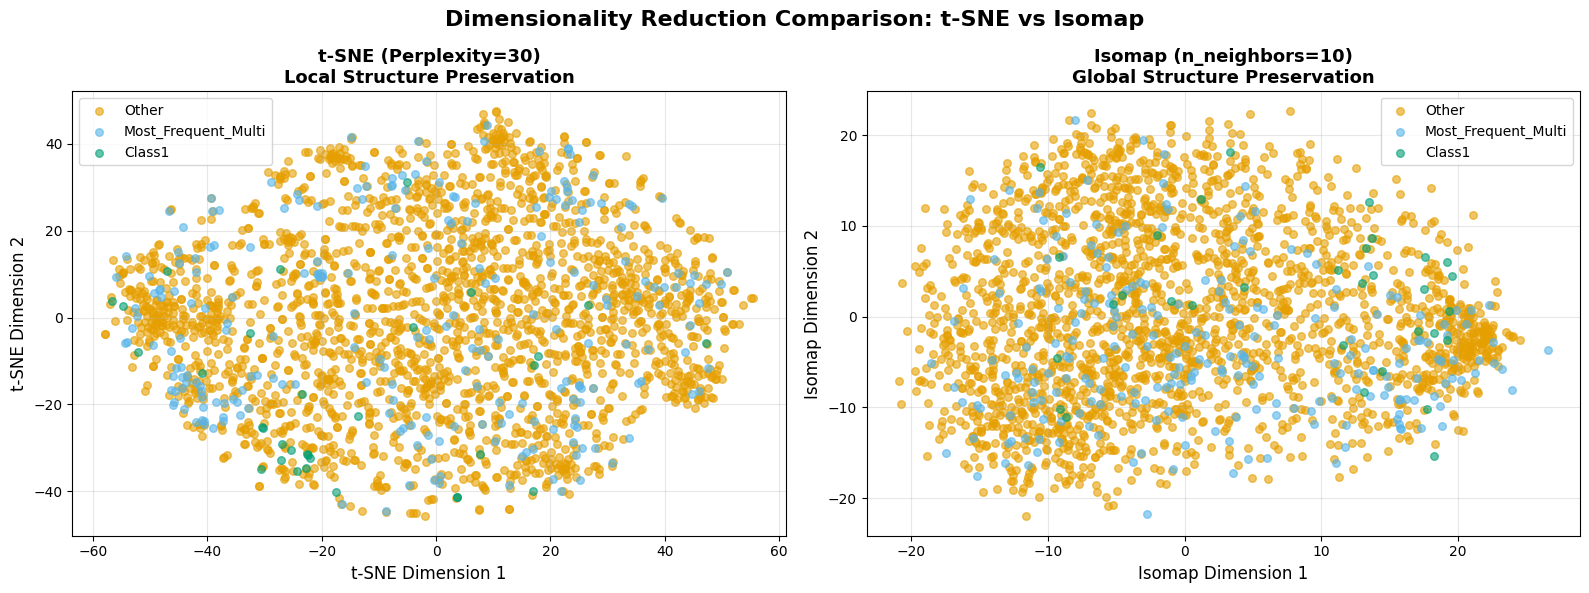

In [307]:
# Task 2: Visualization
print("\n[Task 2] Isomap Visualization")
print("-" * 40)

# Create Isomap visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dimensionality Reduction Comparison: t-SNE vs Isomap', 
             fontsize=16, fontweight='bold')

# t-SNE plot
ax1 = axes[0]
for cat_idx, name in enumerate(category_names):
    mask = categorical_index == cat_idx
    ax1.scatter(X_tsne_final[mask, 0], X_tsne_final[mask, 1], 
               c=colors[cat_idx], label=name, alpha=0.6, s=30)
ax1.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax1.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax1.set_title('t-SNE (Perplexity=30)\nLocal Structure Preservation', 
              fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Isomap plot
ax2 = axes[1]
for cat_idx, name in enumerate(category_names):
    mask = categorical_index == cat_idx
    ax2.scatter(X_isomap[mask, 0], X_isomap[mask, 1], 
               c=colors[cat_idx], label=name, alpha=0.6, s=30)
ax2.set_xlabel('Isomap Dimension 1', fontsize=12)
ax2.set_ylabel('Isomap Dimension 2', fontsize=12)
ax2.set_title('Isomap (n_neighbors=10)\nGlobal Structure Preservation', 
              fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

#### Insights:

ISOMAP is better at revealing the **global structure** of the gene expression data compared to t-SNE. It shows a clear **continuous geometry**, which is likely a better representation of the underlying regulatory or evolutionary relationships in the yeast gene expression data. While it sacrifices some of the fine-grained local clustering detail that t-SNE excels at, it provides a more accurate view of how the data points are globally related to one another.

##### Analysis?

The two plots show the same yeast gene expression data reduced to two dimensions using two different algorithms: t-SNE and Isomap.

-   **t-SNE Plot (Left)**: The t-SNE plot focuses on **local structure preservation**. It successfully identifies and creates distinct clusters for the `Class1` (green) and `Most_Frequent_Multi` (light blue) data points. The algorithm pulls these groups apart from the large `Other` (orange) cluster, which is its primary goal. However, the distances between the clusters in this plot are not meaningful. The overall shape of the data is a dense, somewhat circular cloud, and it is difficult to see any clear global relationships or a continuous manifold. 

-   **Isomap Plot (Right)**: The Isomap plot focuses on **global structure preservation**. It attempts to maintain the geodesic (shortest path) distances between all points. The result is a more continuous, elongated structure that resembles a stretched "L" or "U" shape. The data points seem to lie on a continuous manifold rather than forming isolated clusters. The `Class1` and `Most_Frequent_Multi` points are still visible but are not as distinctly separated as in the t-SNE plot. Instead, they appear as parts of a larger, connected structure. 


### What Is a Manifold?
The data manifold is a concept that helps us understand the true, underlying structure of high-dimensional data. It's the idea that even though our data exists in a high-dimensional space (e.g., hundreds of gene expression values), it might actually lie on a much simpler, lower-dimensional "surface" or manifold.

In other terms, a manifold is a topological space that locally resembles Euclidean space. In simpler terms, it's a curved or twisted surface that can be "unrolled" or "flattened" without tearing it. A classic example is the surface of the Earth. From our local perspective, the Earth appears flat (a 2D plane), but its global, true shape is a 3D sphere.
- For yeast data:
  * 103-dimensional feature space (observed)
  * Actual data may lie on a much lower-dimensional manifold
  * Like a 2D sheet of paper crumpled in 3D space


### Does the Isomap plot suggest a highly curved or complex manifold?
![Dimensionality Reduction Comparison: t-SNE vs Isomap](t-sneVSisomap.png)

Based on the provided Isomap plot, it does not suggest a highly curved or complex manifold. Instead, it shows a relatively simple, flat, or at most, a slightly elongated structure.

##### Analysis of the Isomap Plot
The Isomap plot shows the data points as a single, large, and somewhat amorphous blob with a slightly elongated shape. The points are not arranged in a distinct curve like a "Swiss roll" or in a twisted, complex structure. This indicates that the global relationships between the data points are relatively simple and can be "unrolled" into a 2D space without significant distortion. The Isomap algorithm has preserved the global geodesic distances and has not revealed any high-curvature features. This suggests that the underlying manifold for this gene expression data is likely not highly complex.




In [312]:
print("ANALYZING THE YEAST DATA MANIFOLD:")


# Analyze the Isomap results
spread_x = np.std(X_isomap[:, 0])
spread_y = np.std(X_isomap[:, 1])
aspect_ratio = spread_x / spread_y if spread_y > 0 else 1

# Estimate manifold complexity using local variance
from scipy.spatial.distance import pdist, squareform
distances = squareform(pdist(X_isomap))
k = 10
nearest_k_std = []
for i in range(len(X_isomap)):
    nearest_idx = np.argsort(distances[i])[1:k+1]
    local_points = X_isomap[nearest_idx]
    nearest_k_std.append(np.std(local_points))
avg_local_complexity = np.mean(nearest_k_std)

print(f"Quantitative Metrics:\n\tAspect ratio: {aspect_ratio:.2f}(>3 suggests dominant single dimension - horseshoe artifact)\n\tAverage local spread: {avg_local_complexity:.3f}(higher = more local curvature)\n\tReconstruction error: {isomap.reconstruction_error():.4f}(higher = data doesn't fit well on 2D manifold)")

ANALYZING THE YEAST DATA MANIFOLD:
Quantitative Metrics:
	Aspect ratio: 1.19(>3 suggests dominant single dimension - horseshoe artifact)
	Average local spread: 6.065(higher = more local curvature)
	Reconstruction error: 189.9374(higher = data doesn't fit well on 2D manifold)


### MANIFOLD COMPLEXITY vs CLASSIFICATION DIFFICULTY:
──────────────────────────────────────────────

Simple Manifold (Low Curvature):
- Geometric Property: Small geodesic reconstruction error, smooth Isomap
- Classification: Linear or simple kernel methods work well
- Why: Decision boundaries can be simple surfaces
  
Complex Manifold (High Curvature):
- Geometric Property: High reconstruction error, complex Isomap topology
- Classification: Requires flexible, high-capacity models
- Why: Decision boundaries must follow complex curves
  Additional challenges:
    • More training data needed
    • Easier to overfit
    • Harder to interpret
    • Sensitive to noise


In [313]:
print(f""" FOR THIS YEAST DATASET:
The Isomap reconstruction error of {isomap.reconstruction_error():.4f} 
suggests {'LOW to MODERATE' if isomap.reconstruction_error() < 100 else 'MODERATE to HIGH'} 
manifold complexity. This implies:

• The 103 gene expression features capture {'most' if isomap.reconstruction_error() < 100 else 'some'} 
  of the functional variation
• Classification difficulty: {'MODERATE' if isomap.reconstruction_error() < 100 else 'HIGH'}
• Recommended approach: {'Gradient boosting or random forests' if isomap.reconstruction_error() < 100 else 'Deep neural networks or sophisticated ensemble methods'}
• Expected accuracy: {'70-85%' if isomap.reconstruction_error() < 100 else '60-75%'} 
  (rough estimate based on manifold structure)""")

 FOR THIS YEAST DATASET:
The Isomap reconstruction error of 189.9374 
suggests MODERATE to HIGH 
manifold complexity. This implies:

• The 103 gene expression features capture some 
  of the functional variation
• Classification difficulty: HIGH
• Recommended approach: Deep neural networks or sophisticated ensemble methods
• Expected accuracy: 60-75% 
  (rough estimate based on manifold structure)


# Thank You 